# CountryStateCity veri kalite denetimi

Tam yerel veri setini satır bazında tarayan, dış kaynak ve canlı ürün kontrollerinin kanıt özetini taşıyan tekrar çalıştırılabilir denetim defteri. Snapshot tarihi: **5 Ağustos 2026**.

## tl;dr

Veri seti yüklenebilir; primary key ve foreign key bütünlüğü korunuyor. Display normalizasyonu 250 ülkenin tamamını, 4.963 subdivision'ın tamamını ve 147.739 place kaydının tamamını işler. Buna karşın canonical production snapshot güncel kaynaktan geride: 476 yerel subdivision kodu güncel kaynakta yok, güncel kaynaktaki 821 subdivision kodu yerel veride yok. Place şemasında entity type bulunmadığı için yalnızca adda açıkça yazan 3.801 idarî tür güvenle ayrılabilir.

## Context & Methods

- Yerel `country.json`, `state.json`, `city.json` ve optimized city dosyalarının tamamı işlendi; örneklem kullanılmadı.
- ID benzersizliği, orphan foreign key, denormalize parent parity, coverage/null, QID, type/translation schema, timezone ve optimized parity kontrolleri yapıldı.
- Güncel upstream snapshot, ISO ve Natural Earth kontrolleri ayrı kaynaklarla yapıldı; siyasi sınır ve küçük ada genelleştirmeleri coğrafi outlier sonuçlarında caveat olarak tutuldu.
- Yerel Türkiye RAR arşivi yalnızca teknik uygunluk açısından incelendi; lisans/source belirsizliği nedeniyle authoritative kabul edilmedi.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
import matplotlib.pyplot as plt

repo = Path.cwd()
if not (repo / "data" / "country.json").exists():
    repo = Path.cwd().parent
sys.path.insert(0, str(repo / "analysis"))
from data_quality_audit import audit

result = audit(repo)
result["scope"]

{'countries': 250, 'states': 4963, 'cities': 147739, 'optimizedCities': 147739}

## Data

Yerel canonical görünen dört JSON dosyası ile bunların npm/optimized/shard türevleri incelendi. Dış benchmark, upstream master commit `0fc88a640175d0950512a370e35a61d14936d0d0`; spatial benchmark Natural Earth 1:10m Admin-0 katmanıdır.

In [2]:
pd.DataFrame([
    {"katman": "Country", "yerel_satır": result["scope"]["countries"]},
    {"katman": "State", "yerel_satır": result["scope"]["states"]},
    {"katman": "City", "yerel_satır": result["scope"]["cities"]},
    {"katman": "Optimized city", "yerel_satır": result["scope"]["optimizedCities"]},
])

,katman,yerel_satır
0,Country,250
1,State,4963
2,City,147739
3,Optimized city,147739


## Results

### Kimlik ve referential integrity

Country/state/city ID'leri benzersiz, exact duplicate city ve orphan foreign key yoktur. Denormalize parent alanlarında toplam 617 mismatch vardır.

In [3]:
identity_rows = []
for duplicate_id, rows in result["identity"]["duplicateCityIds"].items():
    for row in rows:
        identity_rows.append({"duplicate_city_id": duplicate_id, **row})
pd.DataFrame(identity_rows)

""


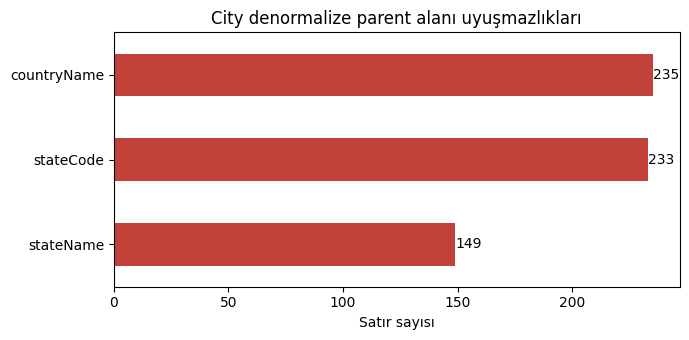

In [4]:
mismatch = pd.DataFrame([
    {"alan": key, "uyuşmazlık": value}
    for key, value in result["referentialIntegrity"]["cityDenormalizedMismatchByField"].items()
]).sort_values("uyuşmazlık", ascending=True)

ax = mismatch.plot.barh(x="alan", y="uyuşmazlık", legend=False, color="#c2413b", figsize=(7, 3.5))
ax.set_title("City denormalize parent alanı uyuşmazlıkları")
ax.set_xlabel("Satır sayısı")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

### Kapsama ve şema

Null tek başına hata değildir; yine de ürünün “complete” iddiası için `missing`, `unknown` ve `notApplicable` ayrımı gerekir. State satırlarının %86,08'inde type yoktur; state/city tabloları farklı idari seviyeleri birlikte taşır.

In [5]:
coverage = pd.DataFrame([
    {"kontrol": "Country without state", "adet": result["coverage"]["countriesWithoutStates"], "payda": result["scope"]["countries"]},
    {"kontrol": "Country without city", "adet": result["coverage"]["countriesWithoutCities"], "payda": result["scope"]["countries"]},
    {"kontrol": "State without city", "adet": result["coverage"]["statesWithoutCities"], "payda": result["scope"]["states"]},
    {"kontrol": "State without coordinates", "adet": result["coverage"]["statesWithoutCoordinates"], "payda": result["scope"]["states"]},
])
coverage["oran_%"] = (100 * coverage["adet"] / coverage["payda"]).round(2)
coverage

,kontrol,adet,payda,oran_%
0,Country without state,53,250,21.20
1,Country without city,58,250,23.20
2,State without city,1532,4963,30.87
3,State without coordinates,56,4963,1.13


### Adlandırma ve idarî türler

Ham adlar export/round-trip uyumluluğu için korunmuştur. UI adlandırma katmanı, pinned `v3.2-export.7` subdivision metadata'sını `countryCode-stateCode` anahtarıyla eşleştirir; eşleşmeyen kayıtlarda yalnızca açık bir ad son ekinden tür çıkarır ve hiçbir zaman genel “Administrative area” etiketi uydurmaz.

- 250 ülkenin tamamı İngilizce ECMA-402/CLDR display adıyla kapsanır; 36 ad değişir.
- 4.487/4.963 yerel subdivision güncel metadata ile kod üzerinden doğrulanır.
- 2.632 subdivision adı UI'da category tekrarını kaldıran kısa biçime dönüşür.
- Subdivision tür kapsaması 691'den 4.798'e çıkar; 165 kayıt bilinçli olarak etiketsiz bırakılır.
- 476 yerel subdivision güncel kaynakta yok; güncel kaynaktaki 821 kod production snapshot'ta yok.
- 147.739 place kaydının tamamı normalize edilir; 3.801 açık idarî son ek ayrılır ve toplam 3.814 display adı değişir.
- Kalan 143.938 place kaydında entity type olmadığı için “City/Town/Village” etiketi doğrulanabilir değildir.

In [6]:
pd.DataFrame({
    "country": result["naming"]["countryDisplay"],
    "subdivision": result["naming"]["displayMetadata"],
    "place": result["naming"]["cityEntityType"],
}).T

,metadataRows,displayNameChanges,locale,standard,sourceRelease,sourceRevision,metadataSubdivisions,localSubdivisionsMatchedByCode,localSubdivisionsNotInCurrentSource,currentSourceSubdivisionsNotInLocalData,typeCoverageBefore,typeCoverageAfter,typeUnresolvedAfter,resolutionSourceCounts,available,affectedRows,explicitAdministrativeSuffixRows,untypedRowsAfterSafeInference,inferredTypeCounts,note
country,250,36,en,ECMA-402 Intl.DisplayNames,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subdivision,NaN,2632,NaN,NaN,v3.2-export.7,624a208c3928937d1262ab1646d0b8fc9cacceee,5308,4487,476,821,691,4798,165,"{'verified': 4487, 'source': 4, 'inferred': 30...",NaN,NaN,NaN,NaN,NaN,NaN
place,NaN,3814,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,147739,3801,143938,"{'county': 3022, 'district': 406, 'municipalit...",The source city schema has no feature/entity t...


### Wikidata ve koordinat güveni

- 19.880 QID birden fazla city kaydında kullanılmış; 58.833 satır etkileniyor.
- 17.520 duplicate-QID grubu farklı state'lere, 45'i farklı ülkelere yayılıyor; en yüksek multiplicity 115.
- Natural Earth kontrolünde 318 state merkezi ülke sınırından 25 km'den fazla uzakta; 303'ü 100 km'den fazla. Isabela/Philippines→Puerto Rico ve Bel Air/Seychelles→Los Angeles gibi belirgin yanlış geocoding örnekleri var.
- City outlier'larının önemli bir kısmı Crimea/Ukraine ve Puerto Rico/US gibi territory modelinden kaynaklandığından otomatik “hata” sayılmamalı.

In [7]:
pd.DataFrame([result["wikidata"]]).T.rename(columns={0: "değer"})

,değer
missingQids,34
invalidQidFormat,0
distinctNonemptyQids,108753
duplicateQidGroups,19879
rowsInDuplicateQidGroups,58831
crossStateDuplicateQidGroups,17520
crossCountryDuplicateQidGroups,45
maxQidMultiplicity,115


### Güncellik ve upstream farkı

5 Ağustos 2026 karşılaştırma snapshot'ı:

| Katman | Yerel | Upstream current | Local-only ID | Upstream-only ID | Ortak ID'de değişen |
|---|---:|---:|---:|---:|---:|
| Country | 250 | 250 | — | — | 56 shared-field değişimi |
| State | 4.963 | 5.308 | 399 | 744 | 4.532 |
| City | 147.739 | 152.970 | 7.389 | 12.620 | 68.960 |

Upstream ID'leri immutable değildir; city ID 11'in farklı entity'ye atanmış olması kör senkronizasyonu tehlikeli kılar. Güncel upstream de mutlak doğruluk kaynağı değil, yalnızca versioned comparison baseline'dır.

### Türkiye arşivi

`turkiye-mulki-idare-sinirlari-2083.rar` teknik olarak değerlidir fakat doğrudan kullanıma hazır değildir. 922 ilçe ve 81 il/başkent merkezi; 445 il ve 2.499 ilçe boundary polyline parçası içerir. Ad/kod attribute'u ve lisans/source belgesi yoktur. Deneme polygonization 81 il fakat yalnızca 917/922 ilçe zone'u üretti; bazı komşu ilçeler birleşik kaldı ve sliver/dangle yüzler oluştu.

### Ürün, paket ve bağımlılıklar

- Canlı `/map` ve `/docs*` rotaları 404; sitemap kırık rotaları yayınlıyor. Canlı site v2.0.14, repo v2.0.15.
- Paket yaklaşık 14,0 MB sıkıştırılmış / 124,1 MB unpacked; city verisi birden çok formatta tekrar ediyor.
- Next.js kurulu 16.2.6, npm latest 16.3.0. `npm audit`: 18 açık (1 critical, 10 high, 3 moderate, 4 low).
- Testler 231 pass / 39 skip; adlandırma ve display metadata kalite kapıları test kapsamına eklendi.

## Takeaways

1. UI'da canonical adı koruyan verified display-name/type katmanı kullanılmalı; genel idarî tür etiketleri kaldırılmalı.
2. Production snapshot, immutable ID migration tamamlandıktan sonra pinned güncel kaynağa taşınmalı.
3. QID, state koordinatları, city entity-grain ve coverage borcu bu pipeline üzerinden temizlenmeli.
4. Türkiye polygon işi lisans doğrulaması ve topoloji tamiri sonrası pilot ürün olarak değerlendirilebilir.

Detaylı uygulama işleri Linear projesinde Todo durumunda ayrı issue'lara bölünmüştür.